In [1]:
using Pkg
Pkg.activate("../scripts/calval")
Pkg.resolve()
using IceFloeTracker
using Images
using DataFrames
using CSVFiles
using CairoMakie
using GLM
using StatsBase

  Activating project at `~/Documents/research/manuscripts/calval_tgrs/scripts/calval`
     Project No packages added to or removed from `~/Documents/research/manuscripts/calval_tgrs/scripts/calval/Project.toml`
    Manifest No packages added to or removed from `~/Documents/research/manuscripts/calval_tgrs/scripts/calval/Manifest.toml`


# Filter Floes
The filter floes function is designed to remove false positives prior to the "merge floes" step. To calibrate the filter floes function, we identify objects from each processing pipeline belonging to no relevant sets based on the manually identified floes.

We first load the data.

In [6]:
dataset = Watkins2026Dataset(;
    url="https://github.com/danielmwatkins/ice-floe-validation-dataset/",
    ref="v0.2",
    cache_dir="/tmp/Watkins2026",
    metadata_path="data/validation_dataset/validation_dataset.csv",
)

#### Run this to use the previously defined test/train split ####
prior_data = DataFrame(load("../data/train_test_split.csv"))
dataset.info[:, :training_sample] = parse.(Bool, prior_data[:, :training_sample])
dataset.info[:, :testing_sample] = parse.(Bool, prior_data[:, :testing_sample])
train_cases = filter(c -> c.training_sample, dataset) 
test_cases = filter(c -> c.testing_sample, dataset);

train_cases.info[:, :lookup_index] = 1:nrow(train_cases.info)
test_cases.info[:, :lookup_index] = 1:nrow(test_cases.info);

cluster_algo = IceDetectionBrightnessPeaksMODIS721(;
        band_7_max=0.16,
        possible_ice_threshold=0.6,
        join_method="union",
        minimum_prominence=0.01,
    )

cleanup_binary_params = (erosion_strel=strel_box((3, 3)), init_max_fill=100, conditional_max_fill=500
)
floe_splitting_params = (max_hole_fill=2000, max_distance=5, max_expand=3)

function clean_split_label(binary_mask, ice_mask, cloud_mask)
    return FSPipeline.dist_morph_split(
        FSPipeline.clean_binary_floes(binary_mask, ice_mask, cloud_mask; cleanup_binary_params...);
        floe_splitting_params...,
    )
end

# Workflows produce labeled arrays, not segmented images
function kmeans_workflow(preproc_gray, fc_masked, land_mask, ice_mask, cloud_mask; k=4, cluster_selection_algorithm=cluster_algo)
    masked_gray = apply_landmask(preproc_gray, land_mask)
    kmeans_result = kmeans_binarization(
        masked_gray, fc_masked; k=k, cluster_selection_algorithm=cluster_algo) .> 0
    return clean_split_label(kmeans_result, ice_mask, cloud_mask)
end

function adaptive_workflow(preproc_gray, land_mask, ice_mask, cloud_mask; window_size=400, percentage=0)
    water_mask = .!(ice_mask .|| cloud_mask .|| land_mask) 
    adaptive_result = binarize(preproc_gray, AdaptiveThreshold(; window_size=window_size, percentage=percentage)) .> 0
    apply_landmask!(adaptive_result, land_mask)
    apply_landmask!(adaptive_result, water_mask)
    return clean_split_label(adaptive_result .> 0, ice_mask, cloud_mask)    
end

adaptive_workflow (generic function with 1 method)

In [7]:
case = train_cases

function fill_missing!(cases; template=Gray.(zeros(Bool, (400, 400))))
    for (idx, img) in enumerate(cases)
        if isnothing(img)
            cases[idx] = template
        end
    end
end

cloud_mask_function = Watkins2026CloudMask(
    band_7_threshold=0.16,
    band_2_threshold=0.34,
    opening_strel=strel_disk(3),
    dilation_strel=strel_disk(2)
)

ice_mask_function = IceDetectionBrightnessMidpoint(; minimum_reflectance=0.45)

@time begin
    tc_imgs = modis_truecolor.(case)
    fc_imgs = modis_falsecolor.(case)
    land_masks = modis_landmask.(case) .|> r -> r .> 0
    cloud_masks = cloud_mask_function.(fc_imgs)
    coastal_buffers = create_coastal_buffer_mask.(land_masks, [strel_box((25,25))])
    
    # joint_mask_buffers = ((x, y) -> x .|| y).(coastal_buffers, cloud_masks)
    
    # Mask images before k-means, preliminary ice mask application
    tc_masked = apply_landmask.(tc_imgs, land_masks)
    fc_masked = apply_landmask.(fc_imgs, land_masks)
    fc_buffered = apply_landmask.(fc_imgs, coastal_buffers)
    band_1 = fc_masked .|> r -> Gray.(blue.(r))
    ice_masks = ice_mask_function.(band_1) .|> r -> r .> 0
    # Masks have to be a full partition for this to work. So if the coastal buffer is used to make
    # the ice mask, it also must be used for the land mask here.
    water_masks = ((x, y, z) -> .!x .&& .!y .&& .!z).(land_masks, cloud_masks, ice_masks)
    
    # reference images
    binary_floes = validated_binary_floes.(case)
    fill_missing!(binary_floes)
end
nothing

  5.174738 seconds (1.89 M allocations: 1.926 GiB, 11.29% gc time, 6.84% compilation time)


In [8]:
preproc_function = FSPipeline.Preprocess(
    diffusion_algorithm = PeronaMalikDiffusion(; λ=0.1, K=0.1, niters=5, g="exponential"),
    adapthisteq_params = (nbins=256, rblocks=2, cblocks=2, clip=5),
    unsharp_mask_params = (radius=50, amount=0.3, threshold=0.01),
)
tiles = get_tiles(tc_imgs[1], (400, 400)) # single tile
preproc_gray = preproc_function.(tc_imgs, land_masks, [tiles]);

In [9]:
adapt_labels = adaptive_workflow.(preproc_gray, land_masks, ice_masks, cloud_masks; window_size=200, percentage=0);
kmeans_labels = kmeans_workflow.(preproc_gray, fc_buffered, land_masks, ice_masks, cloud_masks);

# Get floe properties for training

In [10]:
colnames = [
    :area, :col_centroid, :convex_area, :label, :major_axis_length,
    :max_col, :max_row, :min_col, :min_row, :minor_axis_length, 
    :orientation, :perimeter, :row_centroid, :circularity,
    :cloud_fraction, :b2_reflectance_mean, :b2_reflectance_bdry_mean]

function extended_regionprops(
        img_indexmap, coastal_buffer_mask, cloud_mask, fc_img;
        min_floe_size=100, max_floe_size=90e3, expand_radius=15, colnames=colnames)

    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # Remove floes outside the specified bounds
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)
    maximum(img_indexmap) == 0 && return DataFrame(Dict(r => [] for r in colnames))
    
    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :convex_area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )
    
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2
    
    labels = results_df[:, :label]
    cloud_fractions = Dict(L => mean(cloud_mask[indices[L]]) for L in labels)
    results_df[:, :cloud_fraction] = [cloud_fractions[L] for L in results_df[:, :label]]
    
    # mean reflectance
    segment_mean_reflectance = segment_mean(SegmentedImage(fc_img, img_indexmap))
    b = [segment_mean_reflectance[L] for L in labels]
    results_df[:, :b1_reflectance_mean] = blue.(b)
    results_df[:, :b7_reflectance_mean] = red.(b)
    results_df[:, :b2_reflectance_mean] = green.(b)
    
    # boundary reflectance
    bdry_indexmap = IceFloeTracker.expand_labels(img_indexmap, expand_radius) .- img_indexmap
    bdry_indices = component_indices(bdry_indexmap)

    # Dictionary first, because of the potential for missing labels if the expansion didn't change the size
    # we fill those cases with 0 for the contrast
    bdry_labels = intersect(labels, unique(bdry_indexmap))
    b1 = green.(fc_img)
    b1_bdry_means = Dict(L => mean(b1[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ labels
        if L ∉ bdry_labels
            push!(b1_bdry_means, L => 0)
        end
    end
    
    results_df[:, :b1_reflectance_bdry_mean] = [b1_bdry_means[L] for L in labels]
    results_df[:, :b1_bdry_contrast] = results_df[:, :b1_reflectance_mean] .- results_df[:, :b1_reflectance_bdry_mean]

    b2 = green.(fc_img)
    b2_bdry_means = Dict(L => mean(b2[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ labels
        if L ∉ bdry_labels
            push!(b2_bdry_means, L => 0)
        end
    end
    
    results_df[:, :b2_reflectance_bdry_mean] = [b2_bdry_means[L] for L in labels]
    results_df[:, :b2_bdry_contrast] = results_df[:, :b2_reflectance_mean] .- results_df[:, :b2_reflectance_bdry_mean]
    
    
    return results_df
end

extended_regionprops (generic function with 1 method)

# K-means workflow 
1. Get the relevant sets for each true floe, add "candidate" column to the labeled floes dataframe
2. Test visualization of the selection process
3. Visualize the dataset with relevant joint distributions

In [11]:
# K-means workflow
@time begin
labeled_floes = label_components.(binary_floes)
df_true = extended_regionprops.(labeled_floes, coastal_buffers, cloud_masks, fc_imgs)
df_pred_k = extended_regionprops.(kmeans_labels, coastal_buffers, cloud_masks, fc_imgs);

# Then add the relevant column
for (dft, dfp, lt, lp) in zip(df_true, df_pred_k, labeled_floes, kmeans_labels)
    
    relevant_set = FSPipeline.get_relevant_set(dft, dfp, lt, lp)
    
    matched_labels = Int64[]
    for ll in values(relevant_set)
        for L in ll
            push!(matched_labels, L)
        end
    end
    
    matched_labels = unique(matched_labels);
    
    transform!(dfp, :label => ByRow(r -> r ∈ matched_labels) => :candidate)
    
end

df_pred_k_all = vcat(df_pred_k..., cols=:union);
df_pred_k_all[:, :solidity] = df_pred_k_all[:, :area] ./ df_pred_k_all[:, :convex_area];
save("../data/training_floe_properties_kmeans.csv", df_pred_k_all)
end
nothing

 34.182442 seconds (725.82 M allocations: 27.275 GiB, 6.12% gc time, 21.29% compilation time: 2% of which was recompilation)


# Visualize candidate selection for k-means result

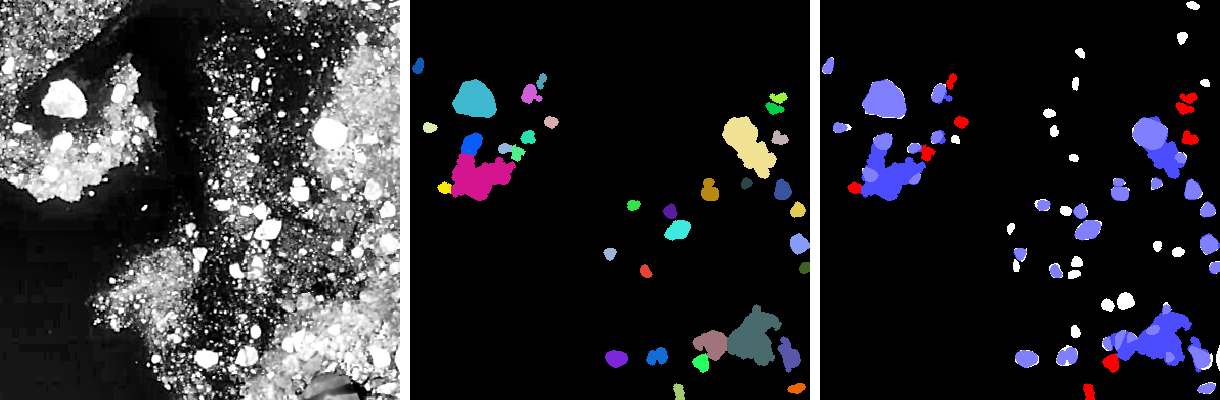

In [12]:
idx = 11
test_img = FSPipeline.assign_labels(kmeans_labels[idx], subset(df_pred_k[idx], :candidate)[:, :label]);

# Test function
overlay = RGBA.(binary_floes[idx])
labeled = kmeans_labels[idx] .> 0
overlay[labeled] .= RGBA.(1, 0, 0)
overlay[test_img .> 0] .= RGBA.(0.3, 0.3, 1)
overlay[test_img .> 0 .&& binary_floes[idx] .> 0] .= RGBA.(0.5, 0.5, 1)

mosaicview(
    preproc_gray[idx], 
    RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], kmeans_labels[idx]))),
    overlay,
npad=10, fillvalue=RGBA(0, 0, 0, 0), nrow=1)

# Visualize candidate selection for k-means result

In [13]:
# Adaptive workflow
@time begin
labeled_floes = label_components.(binary_floes)
df_true = extended_regionprops.(labeled_floes, coastal_buffers, cloud_masks, fc_imgs)
df_pred_a = extended_regionprops.(adapt_labels, coastal_buffers, cloud_masks, fc_imgs);

# Then add the relevant column
for (dft, dfp, lt, lp) in zip(df_true, df_pred_a, labeled_floes, adapt_labels)
    
    relevant_set = FSPipeline.get_relevant_set(dft, dfp, lt, lp)
    
    matched_labels = Int64[]
    for ll in values(relevant_set)
        for L in ll
            push!(matched_labels, L)
        end
    end
    
    matched_labels = unique(matched_labels);
    
    transform!(dfp, :label => ByRow(r -> r ∈ matched_labels) => :candidate)
    
end

df_pred_a_all = vcat(df_pred_a..., cols=:union);
df_pred_a_all[:, :solidity] = df_pred_a_all[:, :area] ./ df_pred_a_all[:, :convex_area];
save("../data/training_floe_properties_adapt.csv", df_pred_a_all)
end
nothing

 52.396009 seconds (1.13 G allocations: 36.773 GiB, 5.96% gc time, 0.50% compilation time: 5% of which was recompilation)


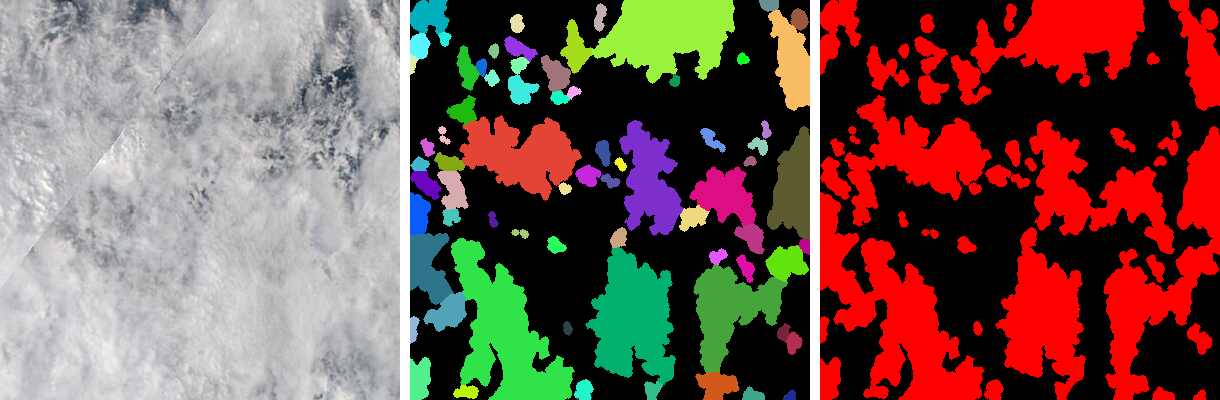

In [14]:
idx = 20
test_img = FSPipeline.assign_labels(adapt_labels[idx], subset(df_pred_a[idx], :candidate)[:, :label]);

# Test function
overlay = RGBA.(binary_floes[idx])
labeled = adapt_labels[idx] .> 0
overlay[labeled] .= RGBA.(1, 0, 0)
overlay[test_img .> 0] .= RGBA.(0.3, 0.3, 1)
overlay[test_img .> 0 .&& binary_floes[idx] .> 0] .= RGBA.(0.5, 0.5, 1)

mosaicview(
    tc_imgs[idx], 
    RGBA.(view_seg_random(SegmentedImage(fc_imgs[idx], adapt_labels[idx]))),
    overlay,
npad=10, fillvalue=RGBA(0, 0, 0, 0), nrow=1)

In [15]:
### Fit model for k-means dataset
using GLM
using StatsBase
using Random

# Make "cloudy" column rather than using Float values
df_pred_k_all[:, :cloudy] = df_pred_k_all[:, :cloud_fraction] .> 0.5
df_pred_k_all[:, :length_scale] = df_pred_k_all[:, :area] .^ 0.5

# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_pred_k_all, :candidate), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data_k = []
gdf = groupby(df_pred_k_all, :candidate)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data_k, group[subset_idx, :])
end

train_df_k = vcat(data_k...);

Drawing 750 samples of each class


In [16]:
### Adaptive

# Make "cloudy" column rather than using Float values
df_pred_a_all[:, :cloudy] = df_pred_a_all[:, :cloud_fraction] .> 0.5
df_pred_a_all[:, :length_scale] = df_pred_a_all[:, :area] .^ 0.5

# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_pred_a_all, :candidate), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data_a = []
gdf = groupby(df_pred_a_all, :candidate)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data_a, group[subset_idx, :])
end

train_df_a = vcat(data_a...);

Drawing 893 samples of each class


In [17]:
# Merged results
train_df_ak = vcat(vcat(data_a...), vcat(data_k...));

In [18]:
# Make "cloudy" column rather than using Float values
df_true_all = vcat(df_true..., cols=:union);
df_true_all[:, :solidity] = df_true_all[:, :area] ./ df_true_all[:, :convex_area];
df_true_all[:, :cloudy] = df_true_all[:, :cloud_fraction] .> 0.5
df_true_all[:, :length_scale] = df_true_all[:, :area] .^ 0.5;

In [90]:
percentile(df_true_all.circularity, 0.01)

0.28039647501908876

In [89]:
percentile(df_true_all.b1_reflectance_mean, 0.01)

0.45418694453537467

In [19]:
# Select subset such that the classes are balanced between candidates and non-candidates

rng = Random.default_rng(300)
n = minimum(combine(groupby(df_true_all, :cloudy), nrow)[:, :nrow])
println("Drawing ", n, " samples of each class")

data = []
gdf = groupby(df_true_all, :cloudy)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n; replace=false, ordered=true)
    push!(data, group[subset_idx, :])
end
train_df = vcat(data...) # true samples
train_df[:, :candidate] .= true

n_false = round(Int64, n/2)

# Subset of non-candidate floes, divide equally into cloudy and noncloudy
### false_positives_k
data_k = []
gdf = groupby(subset(df_pred_k_all, :candidate => r -> .!r), :cloudy)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n_false; replace=false, ordered=true)
    push!(data_k, group[subset_idx, :])
end

### false_postives_a
data_a = []
gdf = groupby(subset(df_pred_a_all, :candidate => r -> .!r), :cloudy)
for group in gdf
    subset_idx = StatsBase.sample(rng, 1:nrow(group), n_false; replace=false, ordered=true)
    push!(data_a, group[subset_idx, :])
end

train_df = vcat(train_df, vcat(data_k...), vcat(data_a...));
nrow(train_df)

Drawing 365 samples of each class


1458

# Choosing the simplest model
Each combination of variables is possible. We want to have a lower BIC, generally, which weighs the complexity against the skill. AIC is also often used, so we check whether the answers are different in that case.

In [21]:
Pkg.add("Combinatorics")
using Combinatorics

    Updating registry at `~/.julia/registries/HolyLabRegistry`
    Updating git-repo `https://github.com/HolyLab/HolyLabRegistry.git`
    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Combinatorics ─ v1.1.0
    Updating `~/Documents/research/manuscripts/calval_tgrs/scripts/calval/Project.toml`
  [861a8166] + Combinatorics v1.1.0
    Updating `~/Documents/research/manuscripts/calval_tgrs/scripts/calval/Manifest.toml`
  [861a8166] + Combinatorics v1.1.0
Precompiling packages...
   1115.6 ms  ✓ Combinatorics
    843.0 ms  ✓ Measurements → MeasurementsRecipesBaseExt
    775.3 ms  ✓ Conda
   2776.4 ms  ✓ Latexify
   2636.1 ms  ✓ Measurements → MeasurementsSpecialFunctionsExt
   1008.6 ms  ✓ Latexify → SparseArraysExt
    818.4 ms  ✓ Unitful → LatexifyExt
   5930.9 ms  ✓ Qt6Base_jll
   7487.6 ms  ✓ PlotThemes
   1103.6 ms  ✓ Qt6ShaderTools_jll
   1168.8 ms  ✓ Qt6Svg_jll
   8097.3 ms  ✓ RecipesPipeline
   9587.1 ms  ✓ CSV
   2139.4 ms  ✓

In [75]:
vars = ["length_scale", "circularity", "b1_reflectance_mean", "b2_reflectance_mean", 
    "b7_reflectance_mean", "b2_bdry_contrast", "b1_bdry_contrast", "cloud_fraction"]

8-element Vector{String}:
 "length_scale"
 "circularity"
 "b1_reflectance_mean"
 "b2_reflectance_mean"
 "b7_reflectance_mean"
 "b2_bdry_contrast"
 "b1_bdry_contrast"
 "cloud_fraction"

## Check correlation

In [74]:
cor(train_df.cloudy, train_df.b7_reflectance_mean)

0.8463506424991201

In [46]:
cor(train_df.cloudy, train_df.cloud_fraction)

0.9826810784187487

In [47]:
cor(train_df.b1_bdry_contrast, train_df.b2_bdry_contrast)

0.9784844817691769

In [48]:
cor(train_df.b1_reflectance_mean, train_df.b2_reflectance_mean)

0.9751244f0

## Get list of variable combinations

In [76]:
list_comb = filter(r -> length(r) > 0, collect(combinations(vars)))
list_comb = filter(r -> !("b1_reflectance_mean" ∈ r && "b2_reflectance_mean" ∈ r), list_comb)
list_comb = filter(r -> !("b1_bdry_contrast" ∈ r && "b2_bdry_contrast" ∈ r), list_comb)
# list_comb = filter(r -> !("cloudy" ∈ r && "cloud_fraction" ∈ r), list_comb)
# list_comb = filter(r -> !("cloudy" ∈ r && "b7_reflectance_mean" ∈ r), list_comb)
list_comb = filter(r -> !("cloud_fraction" ∈ r && "b7_reflectance_mean" ∈ r), list_comb)

107-element Vector{Vector{String}}:
 ["length_scale"]
 ["circularity"]
 ["b1_reflectance_mean"]
 ["b2_reflectance_mean"]
 ["b7_reflectance_mean"]
 ["b2_bdry_contrast"]
 ["b1_bdry_contrast"]
 ["cloud_fraction"]
 ["length_scale", "circularity"]
 ["length_scale", "b1_reflectance_mean"]
 ["length_scale", "b2_reflectance_mean"]
 ["length_scale", "b7_reflectance_mean"]
 ["length_scale", "b2_bdry_contrast"]
 ⋮
 ["circularity", "b2_reflectance_mean", "b7_reflectance_mean", "b2_bdry_contrast"]
 ["circularity", "b2_reflectance_mean", "b7_reflectance_mean", "b1_bdry_contrast"]
 ["circularity", "b2_reflectance_mean", "b2_bdry_contrast", "cloud_fraction"]
 ["circularity", "b2_reflectance_mean", "b1_bdry_contrast", "cloud_fraction"]
 ["length_scale", "circularity", "b1_reflectance_mean", "b7_reflectance_mean", "b2_bdry_contrast"]
 ["length_scale", "circularity", "b1_reflectance_mean", "b7_reflectance_mean", "b1_bdry_contrast"]
 ["length_scale", "circularity", "b1_reflectance_mean", "b2_bdry_contrast

To determine the variables to use in the model, we test every permutation of the 8 variables length scale, circularity, b1, b2, b7, b2_contrast, cloudy, and cloud fraction. We rank the results by the Bayes information criterion (BIC) which weights the likelihood of the model against the complexity of the model. We also examined the AIC, however the results are strongly correlated, so the 

In [50]:
results = DataFrame(
    index = Int64[],
    bic_vals = Float64[],
    aic_vals = Float64[],
    r2_vals = Float64[]
    )
for (idx, covariates) in enumerate(list_comb)
    fm = term(:candidate) ~ sum(term.(covariates))
    logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
    push!(results, [idx, round(bic(logit_true), digits=1), round(aic(logit_true), digits=1), round(r2(logit_true, :CoxSnell), digits=2)])
end

In [51]:
first(sort(results, :aic_vals), 5)

Row,index,bic_vals,aic_vals,r2_vals
,Int64,Float64,Float64,Float64
1,101,1209.4,1177.7,0.44
2,100,1212.3,1180.6,0.44
3,103,1218.2,1186.5,0.44
4,74,1213.4,1187.0,0.44
5,105,1219.8,1188.1,0.44


In [52]:
first(sort(results, :bic_vals), 5)

Row,index,bic_vals,aic_vals,r2_vals
,Int64,Float64,Float64,Float64
1,101,1209.4,1177.7,0.44
2,100,1212.3,1180.6,0.44
3,74,1213.4,1187.0,0.44
4,103,1218.2,1186.5,0.44
5,105,1219.8,1188.1,0.44


In [53]:
for x in sort(results, :bic_vals).index[1:5]
    println(x, list_comb[x])
end

101["length_scale", "circularity", "b1_reflectance_mean", "b7_reflectance_mean", "b1_bdry_contrast"]
100["length_scale", "circularity", "b1_reflectance_mean", "b7_reflectance_mean", "b2_bdry_contrast"]
74["length_scale", "circularity", "b1_reflectance_mean", "b1_bdry_contrast"]
103["length_scale", "circularity", "b1_reflectance_mean", "b1_bdry_contrast", "cloudy"]
105["length_scale", "circularity", "b2_reflectance_mean", "b7_reflectance_mean", "b1_bdry_contrast"]


In [54]:
for x in sort(results, :aic_vals).index[1:5]
    println(x, list_comb[x])
end

101["length_scale", "circularity", "b1_reflectance_mean", "b7_reflectance_mean", "b1_bdry_contrast"]
100["length_scale", "circularity", "b1_reflectance_mean", "b7_reflectance_mean", "b2_bdry_contrast"]
103["length_scale", "circularity", "b1_reflectance_mean", "b1_bdry_contrast", "cloudy"]
74["length_scale", "circularity", "b1_reflectance_mean", "b1_bdry_contrast"]
105["length_scale", "circularity", "b2_reflectance_mean", "b7_reflectance_mean", "b1_bdry_contrast"]


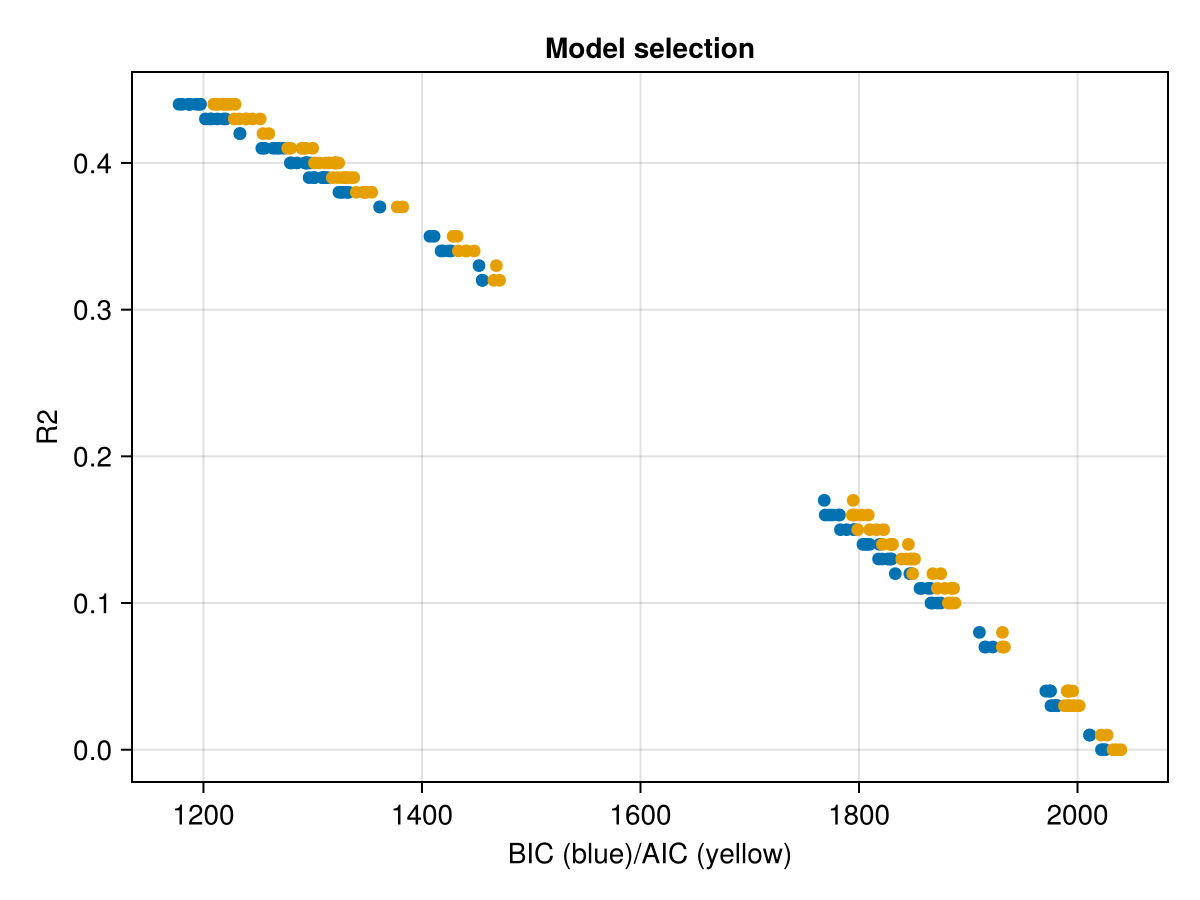

In [55]:
fig = Figure()
ax = CairoMakie.Axis(fig[1,1], title="Model selection", ylabel="R2", xlabel="BIC (blue)/AIC (yellow)")
scatter!(ax, results.aic_vals, results.r2_vals)
scatter!(ax, results.bic_vals, results.r2_vals)

current_figure()

In [395]:
cor(train_df.b1_reflectance_mean, train_df.b2_reflectance_mean)

0.9751249356646466

In [56]:
# Top-performing model based on BIC and AIC.
fm = @formula(candidate ~ length_scale + circularity +  b1_reflectance_mean + b1_bdry_contrast + b7_reflectance_mean)
logit_true = glm(fm, Float64.(train_df), Binomial(), LogitLink())
println("BIC: ", round(bic(logit_true), digits=1), " Pseudo-r2: ", round(r2(logit_true, :CoxSnell), digits=2))
logit_true

BIC: 1209.4 Pseudo-r2: 0.44


StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b1_reflectance_mean + b1_bdry_contrast + b7_reflectance_mean

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -19.3361     1.0958      -17.65    <1e-68  -21.4838     -17.1884
length_scale           0.0588791  0.00668896    8.80    <1e-17    0.0457689    0.0719892
circularity           13.3994     0.73825      18.15    <1e-72   11.9524      14.8463
b1_reflectance_mean    9.29399    0.937032      9.92    <1e-22    7.45744     11.1305
b1_bdry_contrast       3.06192

In [269]:
predicted = predict(logit_true) .> 0.5
# predicted = train_df.circularity .> 0.28 .&& train_df.b1_reflectance_mean .> 0.4
actual = train_df.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(train_df), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         585    107
 1         143    623

Recall:    0.85
Precision: 0.81
Accuracy: 0.83
F-score: 0.83


In [279]:
# Adding the other filters on top
predicted = predict(logit_true) .> 0.5
predicted .= predicted .&& train_df.circularity .> 0.28 .&& train_df.b1_reflectance_mean .> 0.4 .&& train_df.b1_bdry_contrast .> 0.01
actual = train_df.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(train_df), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         591    107
 1         137    623

Recall:    0.85
Precision: 0.82
Accuracy: 0.83
F-score: 0.84


In [62]:
predicted = predict(logit_true, train_df_a) .> 0.5
actual = train_df_a.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(train_df_a), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         737    390
 1         156    503

Recall:    0.56
Precision: 0.76
Accuracy: 0.69
F-score: 0.65


In [63]:
predicted = predict(logit_true, train_df_k) .> 0.5
actual = train_df_k.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(train_df_k), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         632    269
 1         118    481

Recall:    0.64
Precision: 0.8
Accuracy: 0.74
F-score: 0.71


# Error in the full, unbalanced datasets

In [114]:
predicted = predict(logit_true, df_true_all) .> 0.5
actual = df_true_all.area .> 0

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(df_true_all), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         0    163
 1         0    1057

Recall:    0.87
Precision: 1.0
Accuracy: 0.87
F-score: 0.93


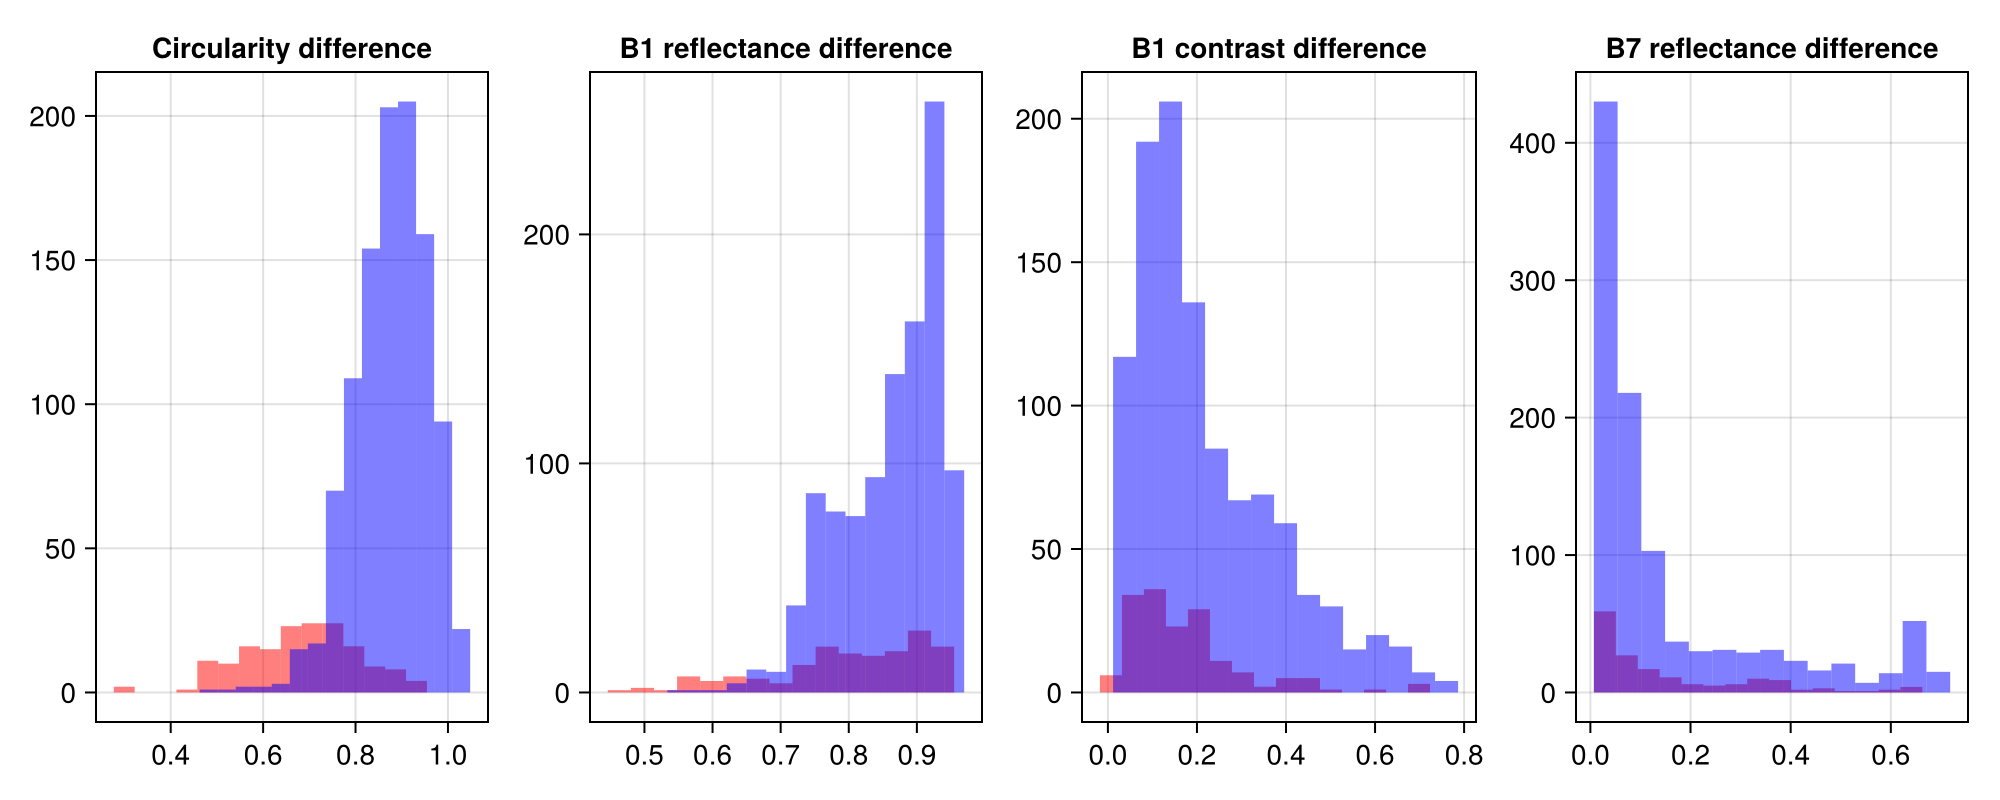

In [210]:
predicted = predict(logit_true, df_true_all) .> 0.5

f = Figure(size=(1000, 400))
ax = CairoMakie.Axis(f[1,1], title="Circularity difference")
hist!(ax, df_true_all[.!predicted, :circularity], color=(:red, 0.5))
hist!(ax, df_true_all[predicted, :circularity], color=(:blue, 0.5))

ax = CairoMakie.Axis(f[1,2], title="B1 reflectance difference")
hist!(ax, df_true_all[.!predicted, :b1_reflectance_mean], color=(:red, 0.5))
hist!(ax, df_true_all[predicted, :b1_reflectance_mean], color=(:blue, 0.5))

ax = CairoMakie.Axis(f[1,3], title="B1 contrast difference")
hist!(ax, df_true_all[.!predicted, :b1_bdry_contrast], color=(:red, 0.5))
hist!(ax, df_true_all[predicted, :b1_bdry_contrast], color=(:blue, 0.5))

ax = CairoMakie.Axis(f[1,4], title="B7 reflectance difference")
hist!(ax, df_true_all[.!predicted, :b7_reflectance_mean], color=(:red, 0.5))
hist!(ax, df_true_all[predicted, :b7_reflectance_mean], color=(:blue, 0.5))

current_figure()

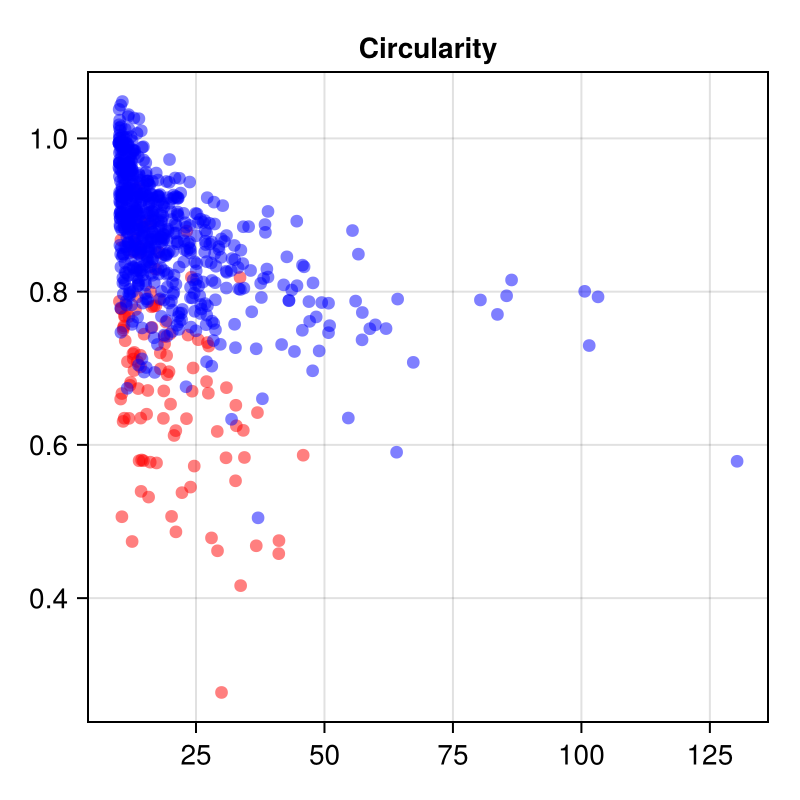

In [131]:
predicted = predict(logit_true, train_df) .> 0.5
train_df[:, :lr_probability] = predict(logit_true, train_df)
f = Figure(size=(400, 400))
ax = CairoMakie.Axis(f[1,1], title="Circularity")
tp = predicted .&& train_df.candidate
fn = .!predicted .&& train_df.candidate
scatter!(ax, train_df[fn, :length_scale], train_df[fn, :circularity], color=(:red, 0.5))
scatter!(ax, train_df[tp, :length_scale], train_df[tp, :circularity], color=(:blue, 0.5))

current_figure()

In [66]:
# Using the whole, unbalanced dataset: how effective is the probability filter alone?
predicted = predict(logit_true, df_pred_k_all) .> 0.5
actual = df_pred_k_all.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(df_pred_k_all), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         2288    269
 1         491    481

Recall:    0.64
Precision: 0.49
Accuracy: 0.78
F-score: 0.56


In [73]:
# Using the whole, unbalanced dataset: how effective is the probability filter alone?
predicted = predict(logit_true, df_pred_a_all) .> 0.5
actual = df_pred_a_all.candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(df_pred_a_all), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         3512    390
 1         682    503

Recall:    0.56
Precision: 0.42
Accuracy: 0.79
F-score: 0.48


## Error in clear-sky vs cloudy cases

In [77]:
# Using the whole, unbalanced dataset: how effective is the filter?
predicted = predict(logit_true, subset(df_pred_k_all, :cloudy)) .> 0.5
actual = subset(df_pred_k_all, :cloudy).candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow(subset(df_pred_k_all, :cloudy)), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         1742    101
 1         336    89

Recall:    0.47
Precision: 0.21
Accuracy: 0.81
F-score: 0.29


In [78]:
# Using the whole, unbalanced dataset: how effective is the filter?
predicted = predict(logit_true, subset(df_pred_k_all, :cloudy => r -> .!r)) .> 0.5
actual =  subset(df_pred_k_all, :cloudy => r -> .!r).candidate

tp = sum(predicted .&& actual)
fp = sum(predicted .&& .!actual)
tn = sum(.!predicted .&& .!actual)
fn = sum(.!predicted .&& actual)

println(" Actual:   0      1")
println("Predicted" )
println(" 0         ", tn, "    ", fn)
println(" 1         ", fp, "    ", tp)
println()
println("Recall:    ", round(tp / (tp + fn), digits=2))
println("Precision: ", round(tp / (tp + fp), digits=2))
println("Accuracy: ", round((tp + tn) / nrow( subset(df_pred_k_all, :cloudy => r -> .!r)), digits=2))
println("F-score: ", round((2*tp) / (2 * tp + fp + fn), digits=2))

 Actual:   0      1
Predicted
 0         546    168
 1         155    392

Recall:    0.7
Precision: 0.72
Accuracy: 0.74
F-score: 0.71


In [231]:
"""
    filter_floes(
    img_indexmap,
    coastal_buffer_mask,
    cloud_mask,
    falsecolor_image;
    min_floe_size=100,
    max_floe_size=90_000,
    expand_radius=15,
    filter_function=LogisticFilterFunction # needs to operate on a dataframe
)

Filter the image indexmap using object-wise properties. Removes objects which overlap the coastal buffer mask,
exceed the size limits, and have too-low circularity. Then, we apply the filter function to the dataframe
which by default uses a pre-fitted logistic regression function. Returns a dataframe with floe properties.

"""
function filter_floes(
    img_indexmap,
    coastal_buffer_mask,
    cloud_mask,
    falsecolor_image;
    min_floe_size=100,
    max_floe_size=90_000,
    expand_radius=15,
    b1_threshold=0.4,
    min_circularity=0.3,
    filter_function=LogisticRegressionFilter,
    min_probability=0.5,
)
    # 1. Remove objects which overlap the coastal mask
    overlap = unique(img_indexmap[coastal_buffer_mask])
    indices = component_indices(img_indexmap)
    for L in overlap
        img_indexmap[indices[L]] .= 0
    end

    # 2. Remove objects outside the specified size bounds prior to extracting features.
    # This is important since the small features can cause problems in some feature
    # descriptors.
    remove_small_segments!(img_indexmap, min_floe_size)
    remove_large_segments!(img_indexmap, max_floe_size)

    # 3. Get object-wise properties
    results_df = regionprops_table(img_indexmap;
        properties=[:label, :area, :perimeter, :bbox, :centroid,
                    :major_axis_length, :minor_axis_length, :orientation]
    )
    # Return blank image if no floes remain
    nrow(results_df) == 0 && return results_df

    results_df[:, :length_scale] = results_df[:, :area] .^ 0.5
    results_df[:, :circularity] = 4 * π * results_df[:, :area] ./ results_df[:, :perimeter] .^ 2
    subset!(results_df, :circularity => r -> r .> min_circularity)
    nrow(results_df) == 0 && return results_df
   
    results_df[:, :cloud_fraction] =  (r -> mean(cloud_mask[indices[r]])).(results_df[:, :label])
    
    # mean reflectance
    segment_mean_reflectance = segment_mean(SegmentedImage(falsecolor_image, img_indexmap))
    b = [segment_mean_reflectance[L] for L in results_df[:, :label]]
    results_df[:, :b1_reflectance_mean] = blue.(b)
    results_df[:, :b7_reflectance_mean] = red.(b)
    results_df[:, :b2_reflectance_mean] = green.(b)
    
    subset!(results_df, :b1_reflectance_mean => r -> r .> b1_threshold)
    nrow(results_df) == 0 && return results_df
    
    # mean boundary reflectance
    b1 = blue.(falsecolor_image)
    bdry_indexmap = expand_labels(img_indexmap, expand_radius) .- img_indexmap
    bdry_indices = component_indices(bdry_indexmap)
    bdry_labels = intersect(results_df[:, :label], unique(bdry_indexmap))
    b1_bdry_means = Dict(L => mean(b1[bdry_indices[L]]) for L in bdry_labels)
    for L ∈ results_df[:, :label]
        if L ∉ bdry_labels
            push!(b1_bdry_means, L => 0)
        end
    end
    results_df[:, :b1_reflectance_bdry_mean] = [b1_bdry_means[L] for L in results_df[:, :label]]
    results_df[:, :b1_bdry_contrast] = results_df[:, :b1_reflectance_mean] .- results_df[:, :b1_reflectance_bdry_mean]
    results_df[:, :probability] .= filter_function(results_df)
    subset!(results_df, :probability => r -> r .> min_probability)

    return results_df
end

# TODO: dmw -- this could be a struct / functor pair, so the filter takes a FloeProbabilityFunction rather than needing to be LogisticRegression
"""
    LogisticRegressionFilter(df; coefs)

Compute the probability for each DataFrameRow using the logistic function
with coefficients defined in `coefs`. Names should include "intercept" and
names of columns in `df`.

"""
function LogisticRegressionFilter(df;
    coefs=Dict(
        "intercept"           => -19.3361,
        "length_scale"        => 0.0589,
        "circularity"         => 13.399,
        "b1_reflectance_mean" => 9.294,
        "b1_bdry_contrast"    => 3.062,
        "b7_reflectance_mean" => -1.179,
        )
    )
    colnames = [x for x in keys(coefs)]
    b = [x for x in values(coefs)]
    df[:, :intercept] .= 1;
    return 1 ./ (1 .+ exp.(-Matrix(df[:, colnames]) * b))
end


LogisticRegressionFilter

In [230]:
logit_true

StatsModels.TableRegressionModel{GeneralizedLinearModel{GLM.GlmResp{Vector{Float64}, Binomial{Float64}, LogitLink}, GLM.DensePredChol{Float64, LinearAlgebra.CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

candidate ~ 1 + length_scale + circularity + b1_reflectance_mean + b1_bdry_contrast + b7_reflectance_mean

Coefficients:
────────────────────────────────────────────────────────────────────────────────────────
                           Coef.  Std. Error       z  Pr(>|z|)    Lower 95%    Upper 95%
────────────────────────────────────────────────────────────────────────────────────────
(Intercept)          -19.3361     1.0958      -17.65    <1e-68  -21.4838     -17.1884
length_scale           0.0588791  0.00668896    8.80    <1e-17    0.0457689    0.0719892
circularity           13.3994     0.73825      18.15    <1e-72   11.9524      14.8463
b1_reflectance_mean    9.29399    0.937032      9.92    <1e-22    7.45744     11.1305
b1_bdry_contrast       3.06192

# Checking the performance of the logistic regression filter
Setting the threshold to 0 means that all floes will get returned

18-element Vector{Float64}:
 0.5163095847913373
 0.9339029615267681
 0.6765036116756042
 0.8383755657623215
 0.7610369170393305
 0.7905546264644083
 0.7288840417438379
 0.8640149000466569
 0.7877707249277508
 0.7539754440522066
 0.7542264511335179
 0.9116187859225374
 0.9296649020798562
 0.6628359615043113
 0.8858674804997102
 0.6073111575059602
 0.7747164360980312
 0.7702001355225339

In [233]:
true_filtered = filter_floes.(labeled_floes,
    coastal_buffers,
    cloud_masks,
    fc_imgs;
    min_probability=0
);

┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warn

# Can we add a threshold on the contrast to avoid the cloud cases?


In [234]:
min_probability = true_filtered .|> r -> if nrow(r) > 0 minimum(r.probability) else -1 end

115-element Vector{Real}:
  0.18720097191627053
  0.015603237241276106
 -1
 -1
  0.10794911829981915
  0.015060189804366799
  0.05009888945181137
  0.04200253634431776
  0.1398182641052387
  0.5323676308605416
  0.21440036924478995
  0.0561755472183373
  0.08886051345167455
  ⋮
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
  0.8042565210389897
  0.9644515234267597

In [217]:
min_contrast = true_filtered .|> r -> if nrow(r) > 0 minimum(r.b1_bdry_contrast) else -1 end

115-element Vector{Real}:
  0.08971280840242046
  0.02591924082135666
 -1
 -1
  0.03486318952439915
  0.057318959851967444
  0.07939171710897464
  0.004398680846606995
  0.07554978751914099
  0.0077968046638126065
  0.06500377874748331
  0.03328782547058218
  0.07382002416242461
  ⋮
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
 -1
  0.1324505665032607
  0.053420682808253295

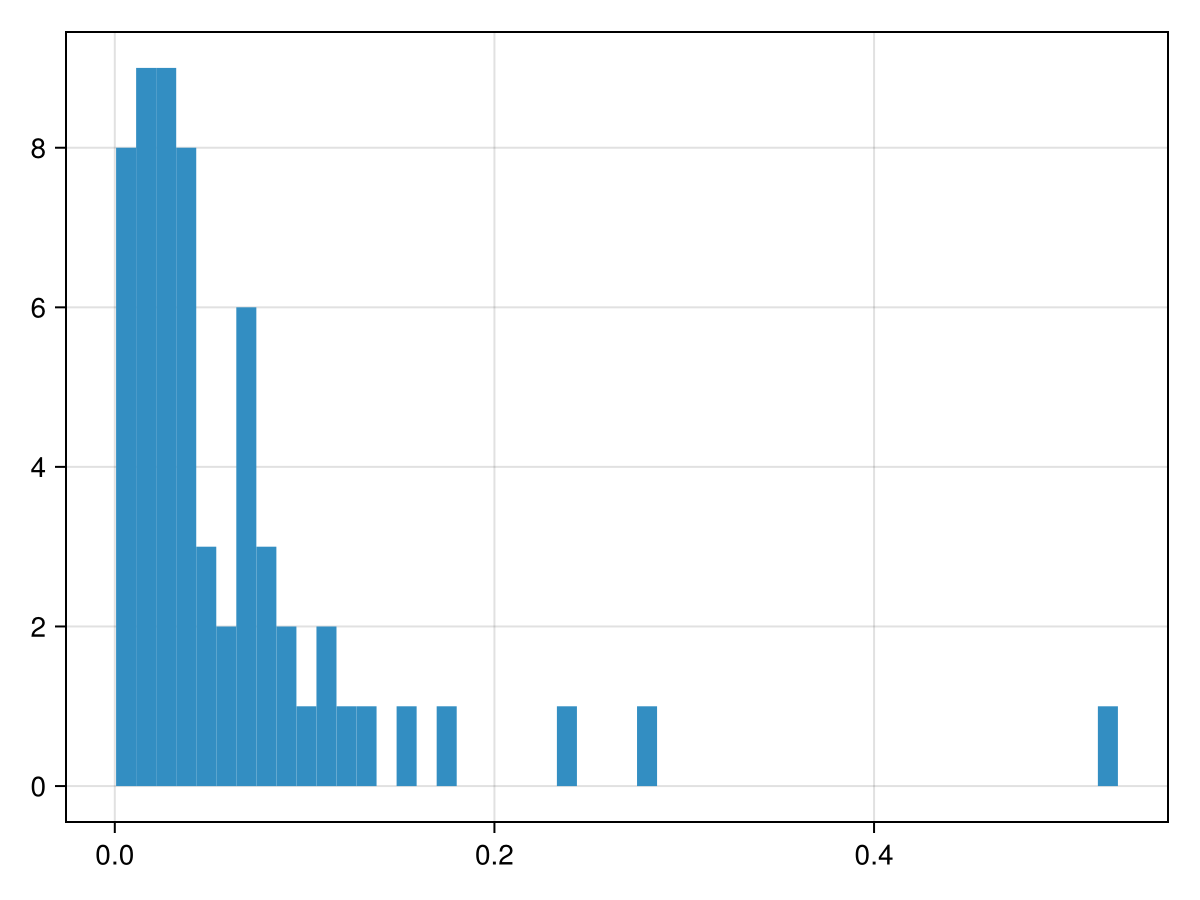

In [220]:
hist(min_contrast[min_contrast .> 0], bins=50)

In [258]:
case_data = train_cases.info[0 .<= min_contrast .<= 0.01, ["case_number", "region", "satellite", "visible_floes", "lookup_index"]]


Row,case_number,region,satellite,visible_floes,lookup_index
,Int64,String,String,String,Int64
1,8,baffin_bay,aqua,yes,8
2,10,baffin_bay,terra,yes,10
3,36,barents_kara_seas,aqua,yes,24
4,53,beaufort_sea,terra,yes,35
5,55,beaufort_sea,aqua,yes,37
6,121,greenland_sea,terra,yes,73
7,148,laptev_sea,terra,yes,88


In [139]:
adapt_filtered = filter_floes.(adapt_labels,
    coastal_buffers,
    cloud_masks,
    fc_imgs;
    min_probability=0
);

In [140]:
kmeans_filtered = filter_floes.(kmeans_labels,
    coastal_buffers,
    cloud_masks,
    fc_imgs;
    min_probability=0
);

┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warning: Labeled image is empty!
└ @ IceFloeTracker.Segmentation ~/.julia/packages/IceFloeTracker/jWpQ0/src/Segmentation/regionprops.jl:555
┌ Warn

Row,case_number,region,satellite
,Int64,String,String
1,3,baffin_bay,aqua


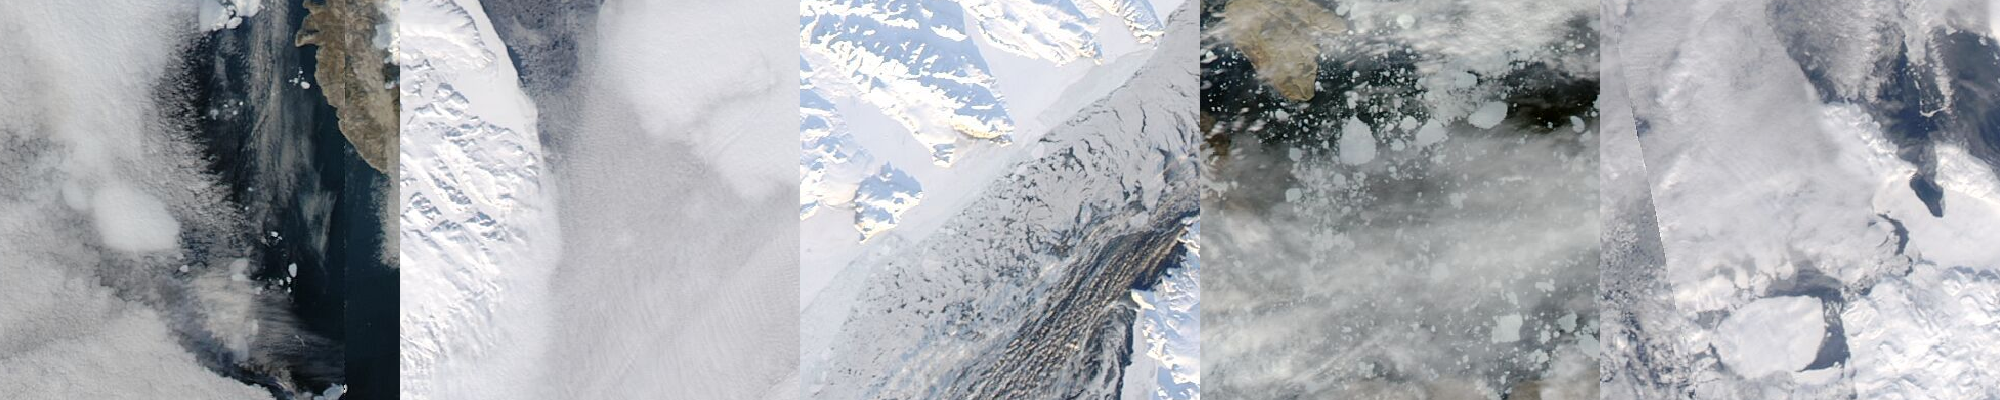

In [159]:
mosaicview(tc_imgs[1:2:10], nrow=1)

In [265]:
idx = 37
case_data = train_cases.info[train_cases.info.lookup_index .== idx, ["case_number", "region", "satellite", "visible_floes"]][1,:]
title = string(case_data.case_number) * " " * case_data.region

"55 beaufort_sea"

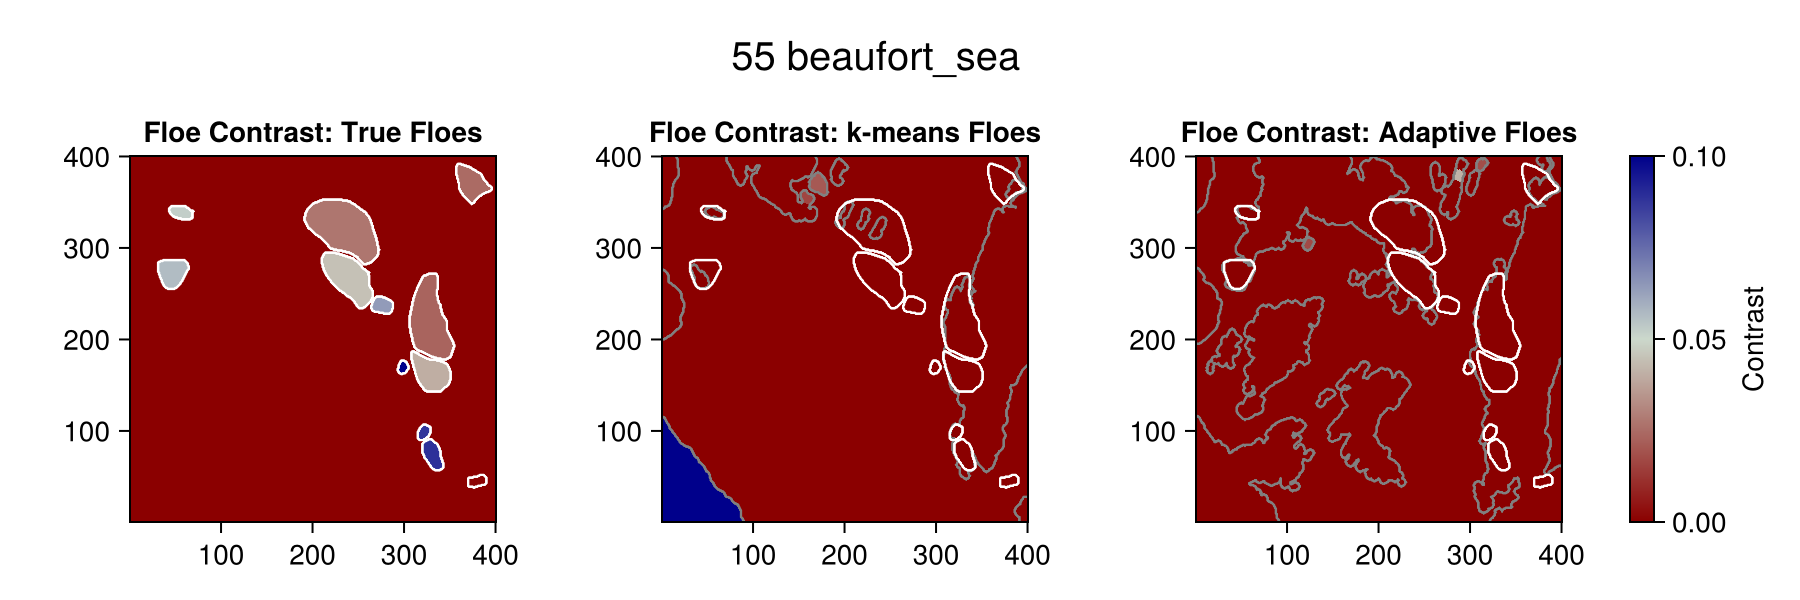

In [266]:
f = Figure(size=(900, 300))

test_df = filter_floes(labeled_floes[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx];
    min_probability=0
);

floe_prob_img = zeros(Float64, size(labeled_floes[idx]))
if nrow(test_df) > 0
    indices = component_indices(labeled_floes[idx])
    for (l, p) in zip(test_df.label, test_df.b1_bdry_contrast)
        l in keys(indices) && (floe_prob_img[indices[l]] .= p)
    end
end
ax = CairoMakie.Axis(f[1,1], title="Floe Contrast: True Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 0.1))
contour!(ax, rotr90(labeled_floes[idx]), levels=[0, 0.5, 1], color=:white)

test_df = filter_floes(kmeans_labels[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx]
);

floe_prob_img = zeros(Float64, size(kmeans_labels[idx]))
if nrow(test_df) > 0
    indices = component_indices(kmeans_labels[idx])
    for (l, p) in zip(test_df.label, test_df.b1_bdry_contrast)
        l in keys(indices) && (floe_prob_img[indices[l]] .= p)
    end
end
ax = CairoMakie.Axis(f[1,2], title="Floe Contrast: k-means Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 0.1))
contour!(ax, rotr90(kmeans_labels[idx]), levels=[0, 0.5, 1], color=:gray)
contour!(ax, rotr90(labeled_floes[idx]), levels=[0, 0.5, 1], color=:white)

test_df = filter_floes(adapt_labels[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx]
);

floe_prob_img = zeros(Float64, size(adapt_labels[idx]))
indices = component_indices(adapt_labels[idx])
for (l, p) in zip(test_df.label, test_df.b1_bdry_contrast)
    l in keys(indices) && (floe_prob_img[indices[l]] .= p)
end

ax = CairoMakie.Axis(f[1,3], title="Floe Contrast: Adaptive Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 0.1))
contour!(ax, rotr90(adapt_labels[idx]), levels=[0, 0.5, 1], color=:gray)
contour!(ax, rotr90(labeled_floes[idx]), levels=[0, 0.5, 1], color=:white)
CairoMakie.Colorbar(f[1, 4], c, label="Contrast", colorrange=(0, .1))

supertitle = Label(f[0, :], title, fontsize = 20, tellwidth=false)

current_figure()

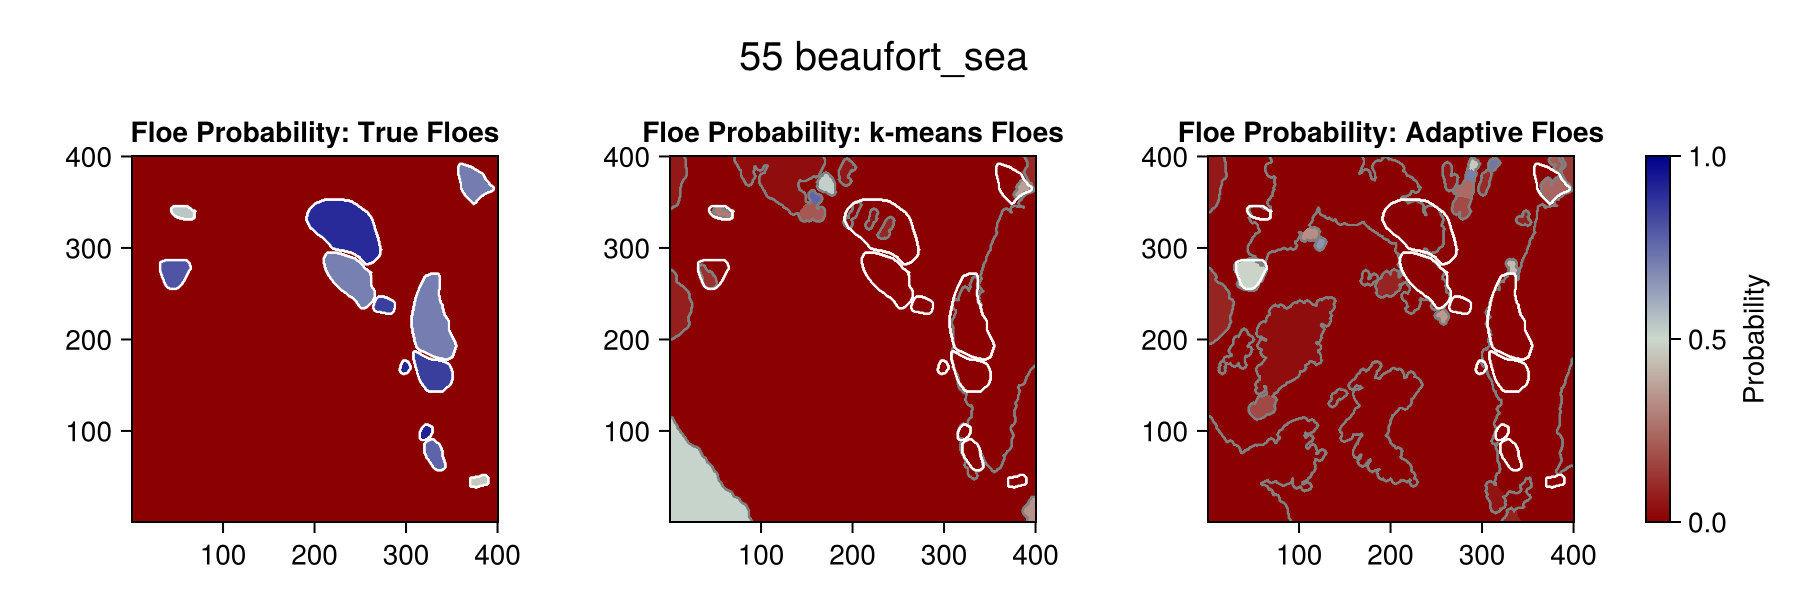

In [267]:
f = Figure(size=(900, 300))

test_df = filter_floes(labeled_floes[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx];
    min_probability=0
);

floe_prob_img = zeros(Float64, size(labeled_floes[idx]))
if nrow(test_df) > 0
    indices = component_indices(labeled_floes[idx])
    for (l, p) in zip(test_df.label, test_df.probability)
        l in keys(indices) && (floe_prob_img[indices[l]] .= p)
    end
end
ax = CairoMakie.Axis(f[1,1], title="Floe Probability: True Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 1))
contour!(ax, rotr90(labeled_floes[idx]), levels=[0, 0.5, 1], color=:white)

test_df = filter_floes(kmeans_labels[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx],
    min_probability=0
);

floe_prob_img = zeros(Float64, size(kmeans_labels[idx]))
if nrow(test_df) > 0
    indices = component_indices(kmeans_labels[idx])
    for (l, p) in zip(test_df.label, test_df.probability)
        l in keys(indices) && (floe_prob_img[indices[l]] .= p)
    end
end
ax = CairoMakie.Axis(f[1,2], title="Floe Probability: k-means Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 1))
contour!(ax, rotr90(kmeans_labels[idx]), levels=[0, 0.5, 1], color=:gray)
contour!(ax, rotr90(labeled_floes[idx]), levels=[0, 0.5, 1], color=:white)

test_df = filter_floes(adapt_labels[idx],
    coastal_buffers[idx],
    cloud_masks[idx],
    fc_imgs[idx],
    min_probability=0
);

floe_prob_img = zeros(Float64, size(adapt_labels[idx]))
indices = component_indices(adapt_labels[idx])
for (l, p) in zip(test_df.label, test_df.probability)
    l in keys(indices) && (floe_prob_img[indices[l]] .= p)
end

ax = CairoMakie.Axis(f[1,3], title="Floe Probability: Adaptive Floes", aspect=1)
c = heatmap!(ax, rotr90(floe_prob_img), colormap=:redsblues, colorrange=(0, 1))
contour!(ax, rotr90(adapt_labels[idx]), levels=[0, 0.5, 1], color=:gray)
contour!(ax, rotr90(labeled_floes[idx]), levels=[0, 0.5, 1], color=:white)
CairoMakie.Colorbar(f[1, 4], c, label="Probability", colorrange=(0, 1))

supertitle = Label(f[0, :], title, fontsize = 20, tellwidth=false)

current_figure()

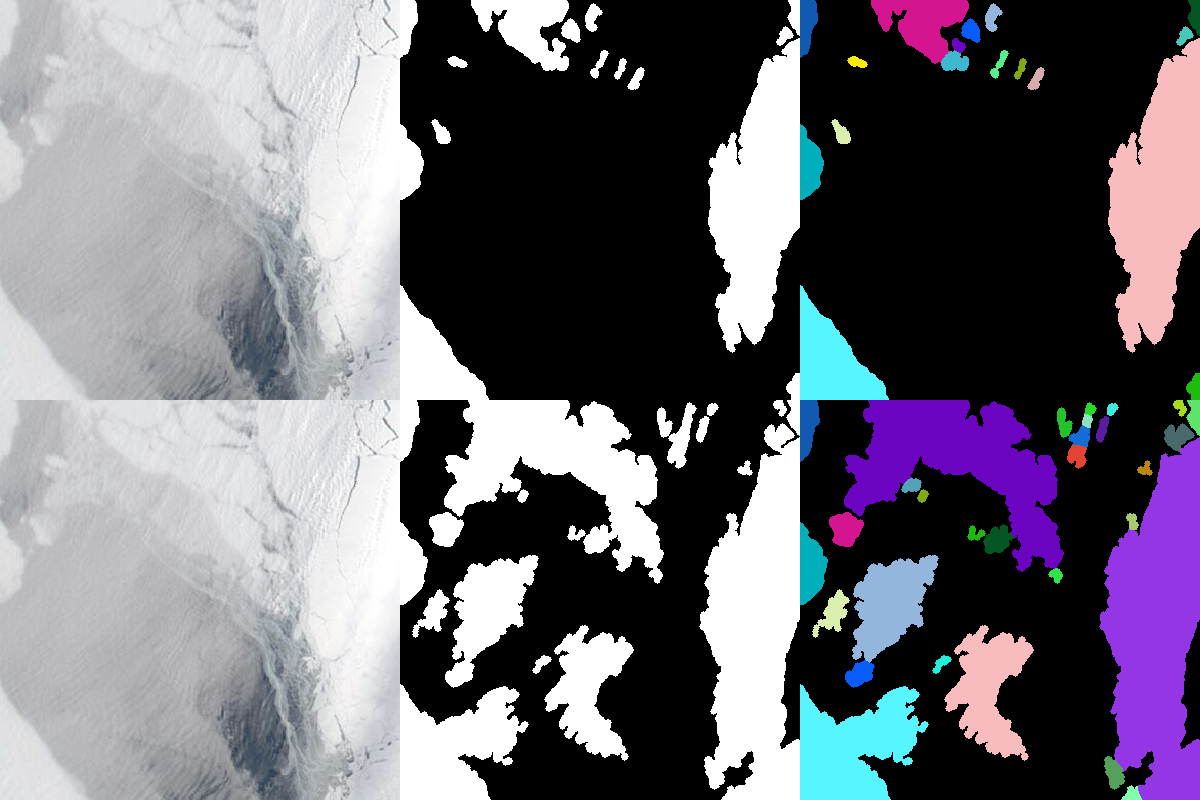

In [268]:
mosaicview(
    mosaicview(tc_imgs[idx], Gray.(kmeans_labels[idx] .> 0), view_seg_random(SegmentedImage(fc_imgs[idx], kmeans_labels[idx])), nrow=1),
    mosaicview(tc_imgs[idx], Gray.(adapt_labels[idx] .> 0), view_seg_random(SegmentedImage(fc_imgs[idx], adapt_labels[idx])), nrow=1),
nrow=2)

In [248]:
test_df

Row,area,col_centroid,label,major_axis_length,max_col,max_row,min_col,min_row,minor_axis_length,orientation,perimeter,row_centroid,length_scale,circularity,cloud_fraction,b1_reflectance_mean,b7_reflectance_mean,b2_reflectance_mean,b1_reflectance_bdry_mean,b1_bdry_contrast,intercept,probability
,Int64,Any,Int64,Any,Int64,Int64,Int64,Int64,Any,Any,Float64,Any,Float64,Float64,Float64,Float32,Float32,Float32,Float64,Float64,Int64,Float64
1,567,191.063,12,34.045,205,291,177,258,21.7863,-0.399281,108.19,273.951,23.8118,0.608723,1.0,0.831648,0.567564,0.837284,0.822376,0.00927215,1,0.0636411
2,566,193.786,13,30.1305,209,191,180,161,25.5773,0.293871,112.326,177.336,23.7908,0.563724,1.0,0.798621,0.609597,0.806706,0.756788,0.0418328,1,0.0279299
3,1193,210.163,15,55.0277,238,261,186,228,30.7985,-1.34959,177.131,241.914,34.5398,0.477817,1.0,0.836717,0.577158,0.839314,0.814466,0.0222518,1,0.0233092
4,503,203.451,17,35.3322,217,400,190,369,18.5769,-0.679572,96.5685,384.988,22.4277,0.677808,1.0,0.856148,0.611782,0.858167,0.841257,0.0148913,1,0.160863
5,961,223.749,21,40.9109,243,201,204,162,35.1936,-0.79124,187.995,184.12,31.0,0.341697,1.0,0.818119,0.582299,0.824987,0.802368,0.0157507,1,0.00255663
6,499,217.393,22,28.616,229,228,204,202,23.2381,-0.229852,99.598,214.395,22.3383,0.632134,1.0,0.826814,0.58118,0.83138,0.807622,0.0191918,1,0.0763895
7,335,216.084,24,24.4898,225,374,207,348,18.0755,0.0437102,78.4264,361.373,18.303,0.684432,1.0,0.859011,0.62469,0.859187,0.837935,0.0210764,1,0.144838
8,460,298.026,37,27.7273,310,223,284,194,22.9941,-0.669568,96.8112,209.652,21.4476,0.616761,1.0,0.849061,0.59967,0.84994,0.818542,0.0305198,1,0.0736968
9,181,313.011,39,17.5347,320,249,307,232,13.2366,-0.132055,51.4558,241.144,13.4536,0.859051,1.0,0.85044,0.603401,0.84966,0.835774,0.0146661,1,0.550881


In [209]:
test_df

Row,area,col_centroid,label,major_axis_length,max_col,max_row,min_col,min_row,minor_axis_length,orientation,perimeter,row_centroid,length_scale,circularity,cloud_fraction,b1_reflectance_mean,b7_reflectance_mean,b2_reflectance_mean,b1_reflectance_bdry_mean,b1_bdry_contrast,intercept,probability
,Int64,Any,Int64,Any,Int64,Int64,Int64,Int64,Any,Any,Float64,Any,Float64,Float64,Float64,Float32,Float32,Float32,Float64,Float64,Int64,Float64
1,444,9.77027,1,32.2012,25,28,1,1,20.19,-0.548191,92.0416,11.3919,21.0713,0.658604,1.0,0.951869,0.552776,0.998161,0.951518,0.000350705,1,0.999639
2,2822,35.1527,3,89.6318,87,304,1,250,46.7938,1.49503,301.557,277.085,53.1225,0.389966,1.0,0.973955,0.511235,0.998672,0.968518,0.005437,1,0.998475
3,144,7.28472,4,18.2271,16,400,1,388,11.0861,1.23318,49.1066,395.59,12.0,0.7504,1.0,0.969935,0.557053,0.998448,0.964714,0.00522103,1,0.999849
4,458,15.1747,5,29.4507,27,330,2,303,20.444,-0.610532,92.0833,315.806,21.4009,0.678756,1.0,0.970474,0.547045,0.998372,0.964632,0.00584237,1,0.999778
5,206,52.9563,8,25.4962,65,400,40,389,11.293,-1.45559,63.1777,395.976,14.3527,0.64856,1.0,0.971997,0.548638,0.998591,0.965653,0.00634436,1,0.999503
6,128,73.6875,9,16.8265,80,161,68,146,9.81662,-0.611594,43.4558,153.391,11.3137,0.851772,1.0,0.962041,0.489645,0.999418,0.960342,0.00169858,1,0.999959
7,348,97.5287,10,29.2449,113,397,85,372,20.5415,0.861772,105.74,387.259,18.6548,0.39112,1.0,0.973426,0.568404,0.998568,0.967354,0.00607239,1,0.987858
8,147,107.531,12,16.6044,115,294,100,283,11.6324,-1.55264,46.1421,288.313,12.1244,0.867625,1.0,0.969375,0.473817,0.999573,0.969437,-6.17784e-5,1,0.999971
9,342,116.889,14,28.6525,131,259,102,242,15.4505,-1.55204,79.2548,250.675,18.4932,0.684202,1.0,0.971837,0.511743,0.998348,0.968344,0.00349338,1,0.999766
